In [44]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [45]:
df_first = pd.read_csv('../data/all_annotations_30_first.csv')
df_repeated = pd.read_csv('../data/all_annotations_30_repeated.csv')

df_first['updated_at'] = pd.to_datetime(df_first['updated_at'])
df_repeated['updated_at'] = pd.to_datetime(df_repeated['updated_at'])

In [46]:
def compute_annotation_times(df, min_minutes=1, max_minutes=20):
    df_sorted = df.sort_values(['annotator', 'updated_at'])
    df_sorted['time_diff'] = df_sorted.groupby('annotator')['updated_at'].diff()
    df_sorted['time_diff_minutes'] = df_sorted['time_diff'].dt.total_seconds() / 60
    
    mask = (df_sorted['time_diff_minutes'] >= min_minutes) & (df_sorted['time_diff_minutes'] <= max_minutes)
    return df_sorted[mask]

In [47]:
times_first = compute_annotation_times(df_first)
times_repeated = compute_annotation_times(df_repeated)

In [48]:
overall_stats = pd.DataFrame({
    'dataset': ['first', 'repeated'],
    'n_valid': [len(times_first), len(times_repeated)],
    'mean_minutes': [times_first['time_diff_minutes'].mean(), times_repeated['time_diff_minutes'].mean()],
    'median_minutes': [times_first['time_diff_minutes'].median(), times_repeated['time_diff_minutes'].median()],
    'std_minutes': [times_first['time_diff_minutes'].std(), times_repeated['time_diff_minutes'].std()]
})
overall_stats

,dataset,n_valid,mean_minutes,median_minutes,std_minutes
0,first,532,6.548874,5.494340,3.978300
1,repeated,579,5.859223,4.694321,3.766967


In [49]:
annotator_stats_first = times_first.groupby('annotator')['time_diff_minutes'].agg(['mean', 'median', 'std', 'count']).reset_index()
annotator_stats_first.columns = ['annotator', 'mean_first', 'median_first', 'std_first', 'count_first']

annotator_stats_repeated = times_repeated.groupby('annotator')['time_diff_minutes'].agg(['mean', 'median', 'std', 'count']).reset_index()
annotator_stats_repeated.columns = ['annotator', 'mean_repeated', 'median_repeated', 'std_repeated', 'count_repeated']

annotator_comparison = annotator_stats_first.merge(annotator_stats_repeated, on='annotator', how='outer')
annotator_comparison['mean_change'] = annotator_comparison['mean_repeated'] - annotator_comparison['mean_first']
annotator_comparison['median_change'] = annotator_comparison['median_repeated'] - annotator_comparison['median_first']
annotator_comparison

,annotator,mean_first,median_first,std_first,count_first,mean_repeated,median_repeated,std_repeated,count_repeated,mean_change,median_change
0,0,8.066068,7.524877,4.507944,24,5.539497,5.148276,2.336294,24,-2.526571,-2.376601
1,1,4.518134,3.958784,2.823578,25,6.012713,5.351694,3.795527,15,1.494580,1.392910
2,2,11.085571,10.890862,4.488000,23,10.550192,11.075034,4.730317,21,-0.535379,0.184172
3,3,4.947443,4.080946,2.356266,16,11.003677,10.590227,4.395270,21,6.056233,6.509281
4,4,1.858120,1.858120,NaN,1,5.460667,5.008349,1.805601,19,3.602548,3.150229
5,5,5.997170,4.530110,3.196351,25,4.779658,3.623496,3.518150,24,-1.217512,-0.906614
6,6,4.380188,3.647743,2.049098,26,3.809994,2.875955,3.070403,24,-0.570194,-0.771789
7,7,14.818855,16.164394,3.779079,7,6.898581,6.590341,2.864349,24,-7.920273,-9.574053
8,8,4.615927,4.444455,2.097636,23,7.892313,7.333386,2.985591,25,3.276387,2.888931
9,9,8.764731,8.403154,3.385829,26,4.348108,3.369755,2.456810,28,-4.416623,-5.033399


In [50]:
common_annotators = annotator_comparison.dropna(subset=['mean_first', 'mean_repeated'])

t_stat, p_value = stats.ttest_rel(common_annotators['mean_first'], common_annotators['mean_repeated'])
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(common_annotators['mean_first'], common_annotators['mean_repeated'])

pd.DataFrame({
    'test': ['paired t-test', 'Wilcoxon signed-rank'],
    'statistic': [t_stat, wilcoxon_stat],
    'p_value': [p_value, wilcoxon_p],
    'significant_0.05': [p_value < 0.05, wilcoxon_p < 0.05]
})

,test,statistic,p_value,significant_0.05
0,paired t-test,1.19226,0.244815,False
1,Wilcoxon signed-rank,114.00000,0.200216,False


In [51]:
speed_change_summary = {
    'mean_first': common_annotators['mean_first'].mean(),
    'mean_repeated': common_annotators['mean_repeated'].mean(),
    'mean_change': common_annotators['mean_change'].mean(),
    'pct_faster': (common_annotators['mean_change'] < 0).sum() / len(common_annotators) * 100,
    'pct_slower': (common_annotators['mean_change'] > 0).sum() / len(common_annotators) * 100
}
pd.DataFrame([speed_change_summary])

,mean_first,mean_repeated,mean_change,pct_faster,pct_slower
0,6.614811,5.915268,-0.699543,64.0,36.0


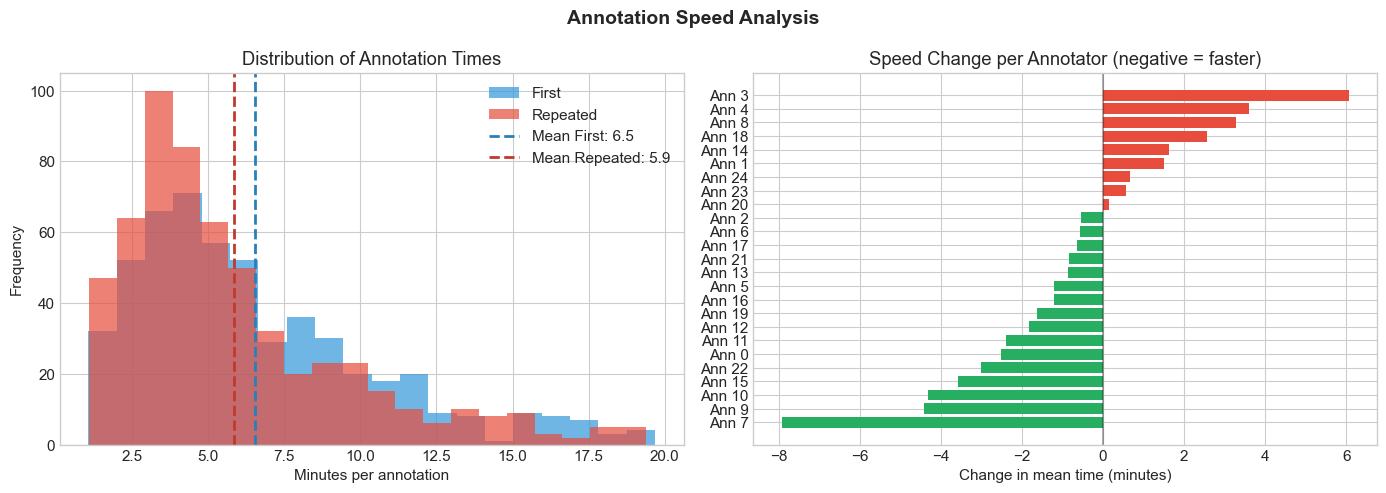

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(times_first['time_diff_minutes'], bins=20, alpha=0.7, label='First', color='#3498db')
axes[0].hist(times_repeated['time_diff_minutes'], bins=20, alpha=0.7, label='Repeated', color='#e74c3c')
axes[0].axvline(times_first['time_diff_minutes'].mean(), color='#2980b9', linestyle='--', linewidth=2, label=f'Mean First: {times_first["time_diff_minutes"].mean():.1f}')
axes[0].axvline(times_repeated['time_diff_minutes'].mean(), color='#c0392b', linestyle='--', linewidth=2, label=f'Mean Repeated: {times_repeated["time_diff_minutes"].mean():.1f}')
axes[0].set_xlabel('Minutes per annotation')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Annotation Times')
axes[0].legend()

sorted_ann = common_annotators.sort_values('mean_change')
colors = ['#27ae60' if x < 0 else '#e74c3c' for x in sorted_ann['mean_change']]
axes[1].barh(range(len(sorted_ann)), sorted_ann['mean_change'], color=colors)
axes[1].set_yticks(range(len(sorted_ann)))
axes[1].set_yticklabels([f"Ann {int(a)}" for a in sorted_ann['annotator']])
axes[1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
axes[1].set_xlabel('Change in mean time (minutes)')
axes[1].set_title('Speed Change per Annotator (negative = faster)')

plt.suptitle('Annotation Speed Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [53]:
def add_order_in_session(df):
    df = df.sort_values(['annotator', 'updated_at']).copy()
    df['order_in_session'] = df.groupby('annotator').cumcount() + 1
    return df

times_first_ord = add_order_in_session(times_first)
times_repeated_ord = add_order_in_session(times_repeated)

In [54]:
progression_first = times_first_ord.groupby('order_in_session')['time_diff_minutes'].agg(['mean', 'median', 'count']).reset_index()
progression_first.columns = ['order', 'mean_first', 'median_first', 'count_first']

progression_repeated = times_repeated_ord.groupby('order_in_session')['time_diff_minutes'].agg(['mean', 'median', 'count']).reset_index()
progression_repeated.columns = ['order', 'mean_repeated', 'median_repeated', 'count_repeated']

progression = progression_first.merge(progression_repeated, on='order', how='outer')
progression.head(20)

,order,mean_first,median_first,count_first,mean_repeated,median_repeated,count_repeated
0,1,7.474980,7.010984,25,7.009117,6.573880,25.0
1,2,7.985265,6.409854,24,7.157523,7.162481,25.0
2,3,7.018089,6.261073,24,7.208501,5.451832,25.0
3,4,5.420502,5.053531,24,7.056452,5.210014,25.0
4,5,8.381272,7.367032,24,6.163222,5.862433,25.0
5,6,6.478815,5.468375,24,5.891932,4.721032,25.0
6,7,6.783083,6.278367,24,6.670731,5.758286,25.0
7,8,7.245903,6.957864,23,5.475579,3.892628,25.0
8,9,5.876393,5.881528,23,4.979972,4.182944,25.0
9,10,7.678741,6.319979,23,6.024642,5.541891,25.0


In [55]:
from scipy.stats import spearmanr

corr_first, p_first = spearmanr(times_first_ord['order_in_session'], times_first_ord['time_diff_minutes'])
corr_repeated, p_repeated = spearmanr(times_repeated_ord['order_in_session'], times_repeated_ord['time_diff_minutes'])

pd.DataFrame({
    'dataset': ['first', 'repeated'],
    'spearman_corr': [corr_first, corr_repeated],
    'p_value': [p_first, p_repeated]
})

,dataset,spearman_corr,p_value
0,first,-0.131272,0.002415
1,repeated,-0.186566,0.000006


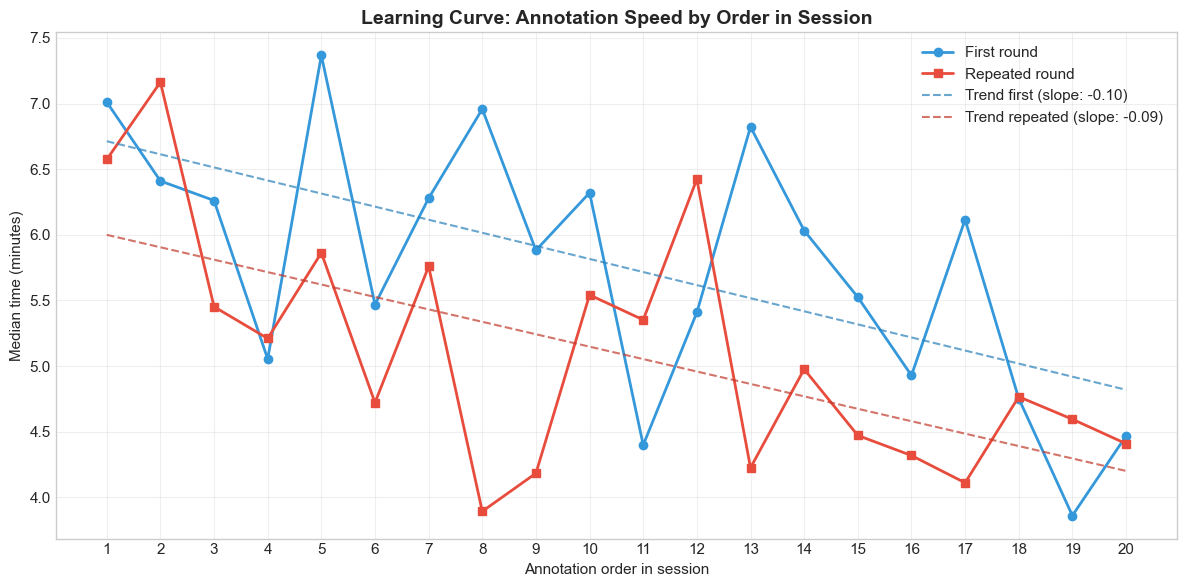

In [56]:
fig, ax = plt.subplots(figsize=(12, 6))

prog_20 = progression[progression['order'] <= 20].copy()

ax.plot(prog_20['order'], prog_20['median_first'], 'o-', label='First round', color='#3498db', linewidth=2, markersize=6)
ax.plot(prog_20['order'], prog_20['median_repeated'], 's-', label='Repeated round', color='#e74c3c', linewidth=2, markersize=6)

z_first = np.polyfit(prog_20['order'], prog_20['median_first'], 1)
z_repeated = np.polyfit(prog_20['order'], prog_20['median_repeated'].dropna(), 1)
ax.plot(prog_20['order'], np.polyval(z_first, prog_20['order']), '--', color='#2980b9', alpha=0.7, label=f'Trend first (slope: {z_first[0]:.2f})')
ax.plot(prog_20['order'], np.polyval(z_repeated, prog_20['order']), '--', color='#c0392b', alpha=0.7, label=f'Trend repeated (slope: {z_repeated[0]:.2f})')

ax.set_xlabel('Annotation order in session')
ax.set_ylabel('Median time (minutes)')
ax.set_title('Learning Curve: Annotation Speed by Order in Session', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xticks(prog_20['order'])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
first_times = times_first['time_diff_minutes'].values
repeated_times = times_repeated['time_diff_minutes'].values

mannwhitney_stat, mannwhitney_p = stats.mannwhitneyu(first_times, repeated_times, alternative='two-sided')
ttest_stat, ttest_p = stats.ttest_ind(first_times, repeated_times)

paired_annotators = set(times_first['annotator'].unique()) & set(times_repeated['annotator'].unique())
first_medians = times_first[times_first['annotator'].isin(paired_annotators)].groupby('annotator')['time_diff_minutes'].median()
repeated_medians = times_repeated[times_repeated['annotator'].isin(paired_annotators)].groupby('annotator')['time_diff_minutes'].median()
common_annotators = first_medians.index.intersection(repeated_medians.index)
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(first_medians[common_annotators], repeated_medians[common_annotators])

results = pd.DataFrame({
    'test': ['Mann-Whitney U', 'Independent t-test', 'Wilcoxon signed-rank (paired by annotator)'],
    'statistic': [mannwhitney_stat, ttest_stat, wilcoxon_stat],
    'p_value': [mannwhitney_p, ttest_p, wilcoxon_p],
    'significant_0.05': [mannwhitney_p < 0.05, ttest_p < 0.05, wilcoxon_p < 0.05]
})
results

,test,statistic,p_value,significant_0.05
0,Mann-Whitney U,171752.000000,0.000900,True
1,Independent t-test,2.967573,0.003066,True
2,Wilcoxon signed-rank (paired by annotator),115.000000,0.209939,False
